# Student Performance Indicator

### LifeCycle of ML project
Understanding the Problem Statement<br>
Data Collection<br>
Data Checks to perforgn<br>
Exploratory data analysis<br>
Data Pre-Processing<br>
Model Training<br>
Choose best model<br>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("data//StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [8]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [9]:
numerical_features = [col for col in df.columns if df[col].dtype != "O"]
categorical_features = [col for col in df.columns if df[col].dtype == "O"]
print(f"Got {len(numerical_features)} Numerical Features: {numerical_features}")
print(f"Got {len(categorical_features)} Categorical Features: {categorical_features}")

Got 3 Numerical Features: ['math score', 'reading score', 'writing score']
Got 5 Categorical Features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


#### Adding the columns of sum of scores and average scores:

In [10]:
df["Score"] = df['math score'] + df['reading score'] + df['writing score']
df['Average'] = df['Score'] / 3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [13]:
reading_full = len(df[df['reading score'] == 100])
maths_full = len(df[df['math score'] == 100])
writing_full = len(df[df['writing score'] == 100])

print("Number of student who got full marks in maths: ", maths_full)
print("Number of student who got full marks in writing: ", writing_full)
print("Number of student who got full marks in reading: ", reading_full)

Number of student who got full marks in maths:  7
Number of student who got full marks in writing:  14
Number of student who got full marks in reading:  17


In [14]:
reading_20 = len(df[df['reading score'] <= 20])
maths_20 = len(df[df['math score'] <= 20])
writing_20 = len(df[df['writing score'] <= 20])

print("Number of student who got full marks in maths: ", maths_20)
print("Number of student who got full marks in writing: ", writing_20)
print("Number of student who got full marks in reading: ", reading_20)

Number of student who got full marks in maths:  4
Number of student who got full marks in writing:  3
Number of student who got full marks in reading:  1


### Data Visualization

<Axes: xlabel='Score', ylabel='Count'>

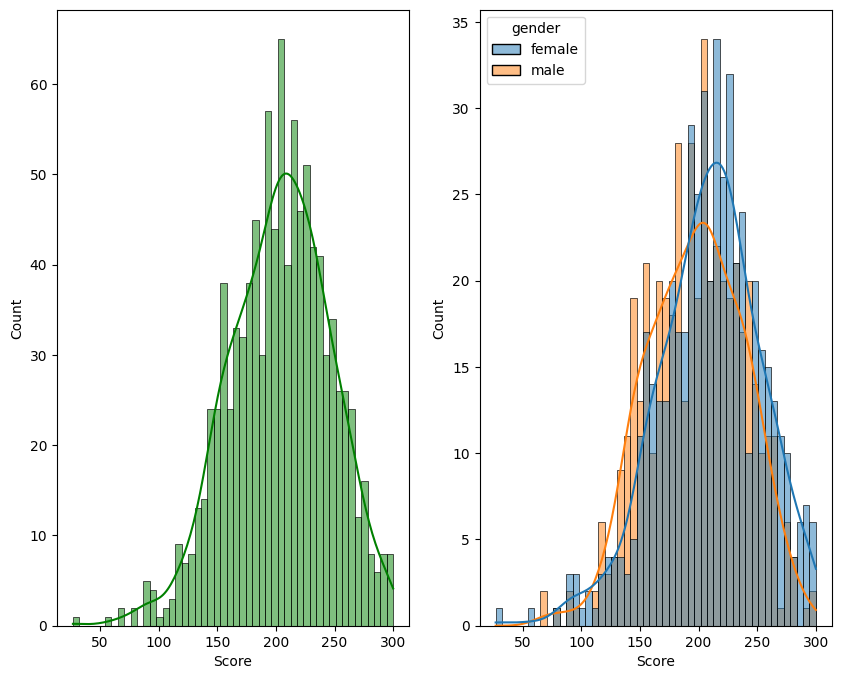

In [32]:
import matplotlib.pyplot as plt
plt.subplots(1,2,figsize = (10,8))
plt.subplot(121)
sns.histplot(data=df,x="Score",bins=50,kde=True,color="g")
plt.subplot(122)
sns.histplot(data=df,x="Score",bins=50,kde=True, hue='gender')

<Axes: xlabel='Average', ylabel='Count'>

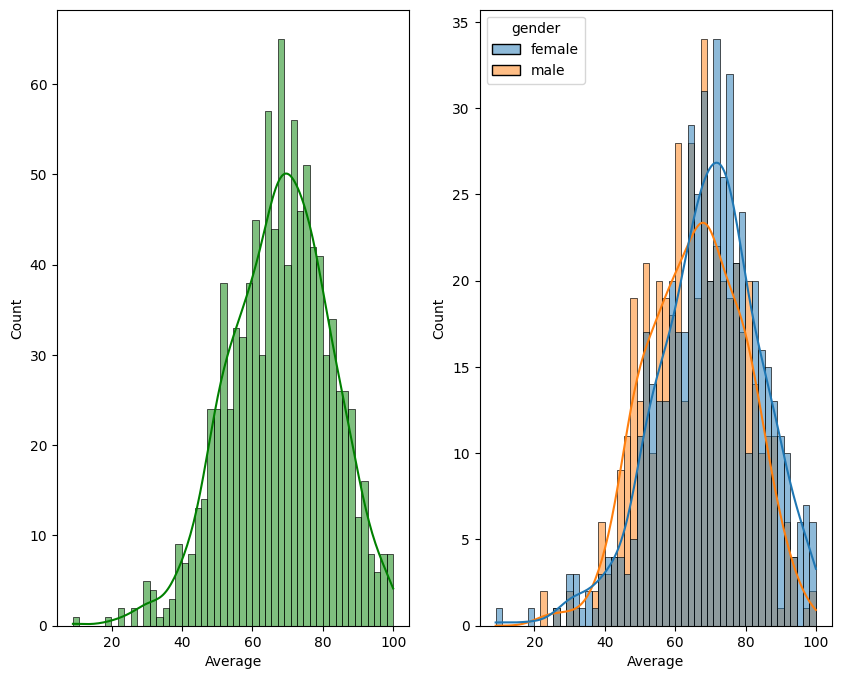

In [33]:
plt.subplots(1,2,figsize = (10,8))
plt.subplot(121)
sns.histplot(data=df,x="Average",bins=50,kde=True,color="g")
plt.subplot(122)
sns.histplot(data=df,x="Average",bins=50,kde=True, hue='gender')

In [34]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [35]:
df.lunch.unique()

array(['standard', 'free/reduced'], dtype=object)

<Axes: xlabel='Average', ylabel='Count'>

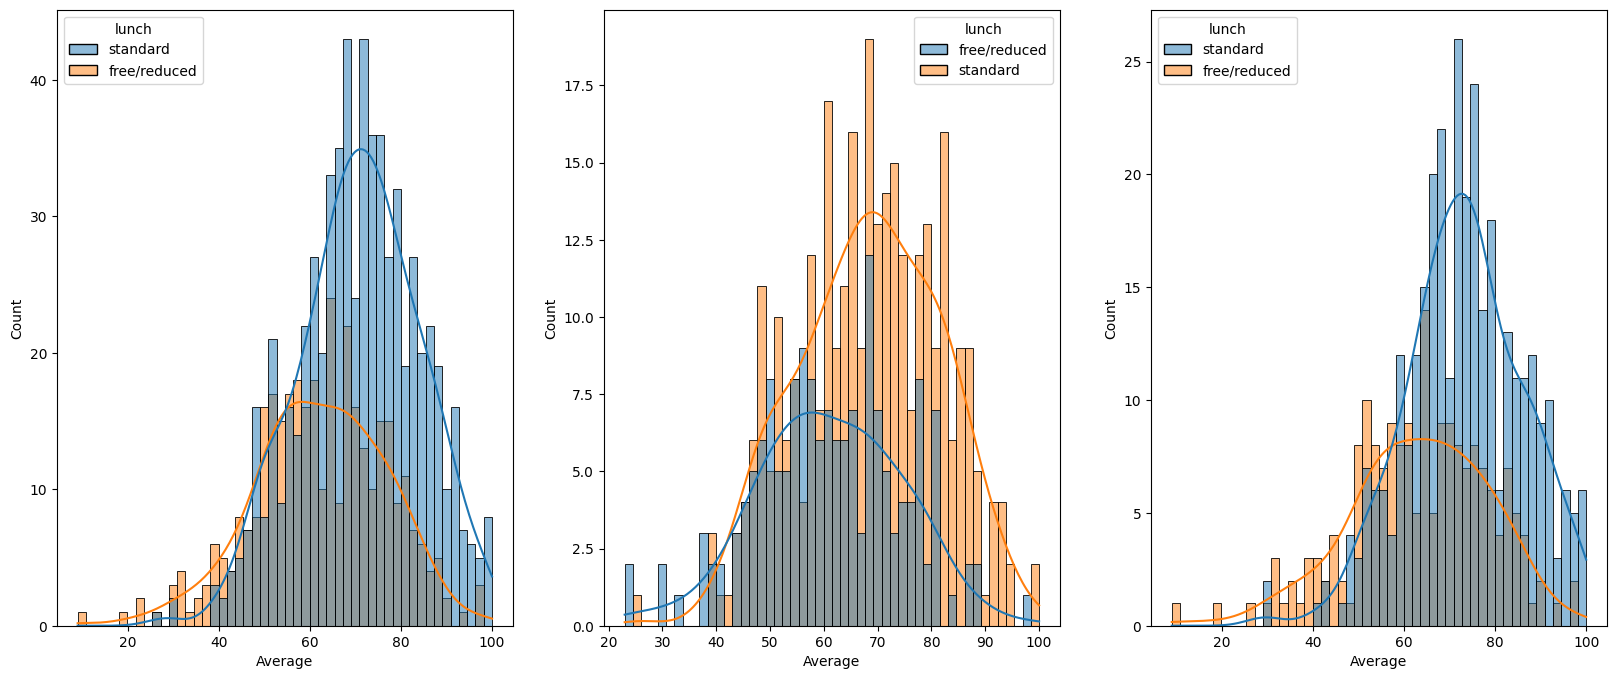

In [38]:
plt.subplots(1,3,figsize = (20,8))
plt.subplot(131)
sns.histplot(data=df,x="Average",bins=50,kde=True,hue = "lunch")
plt.subplot(132)
sns.histplot(data=df[df['gender'] == 'male'],x="Average",bins=50,kde=True, hue='lunch')
plt.subplot(133)
sns.histplot(data=df[df['gender'] == 'female'],x="Average",bins=50,kde=True, hue='lunch')

#####  Insights
- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exams be it a male or a female.

In [39]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


<Axes: xlabel='Average', ylabel='Count'>

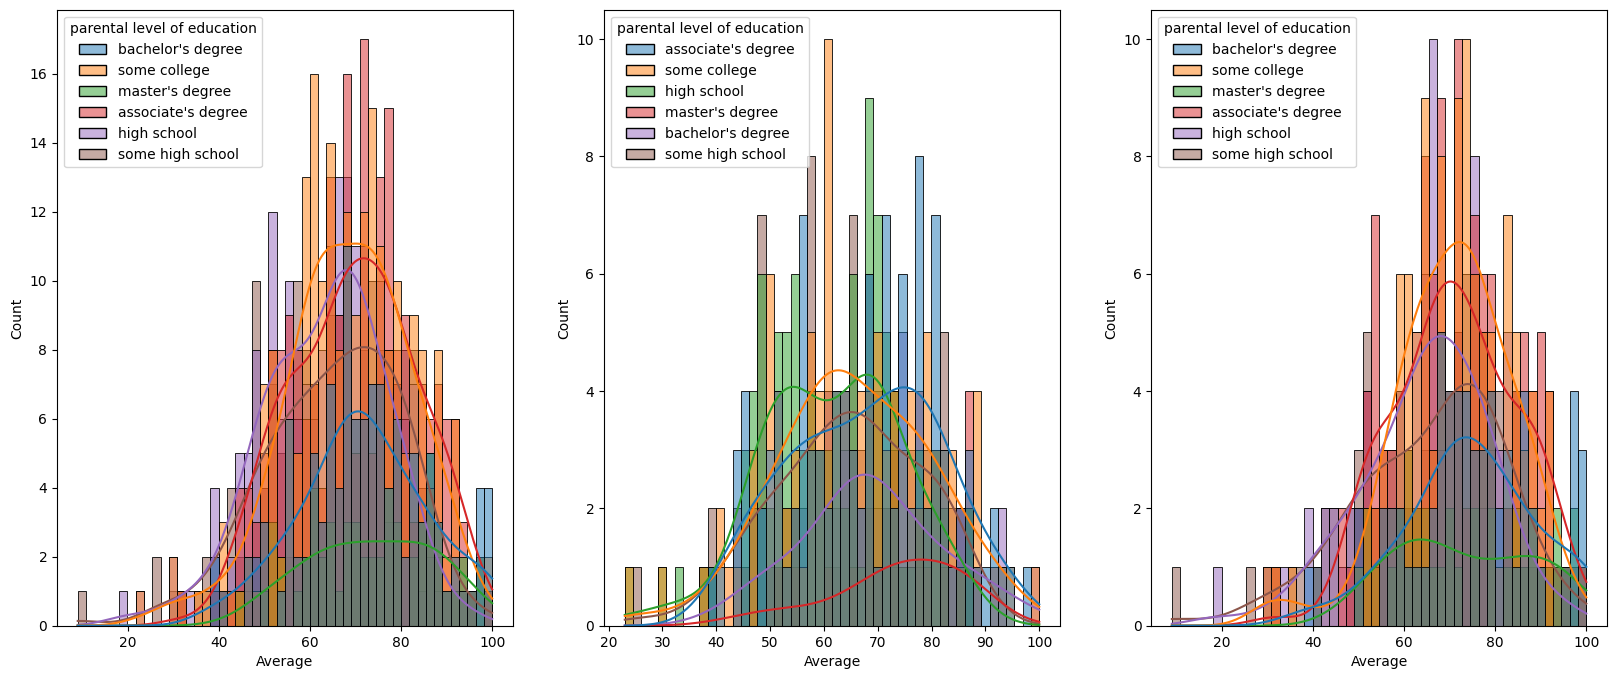

In [40]:
plt.subplots(1,3,figsize = (20,8))
plt.subplot(131)
sns.histplot(data=df,x="Average",bins=50,kde=True,hue = "parental level of education")
plt.subplot(132)
sns.histplot(data=df[df['gender'] == 'male'],x="Average",bins=50,kde=True, hue='parental level of education')
plt.subplot(133)
sns.histplot(data=df[df['gender'] == 'female'],x="Average",bins=50,kde=True, hue='parental level of education')

#####  Insights
- In general parent's education don't help student perform well in exam.
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
- 3rd plot we can see there is no effect of parent's education on female students.

<Axes: xlabel='Average', ylabel='Count'>

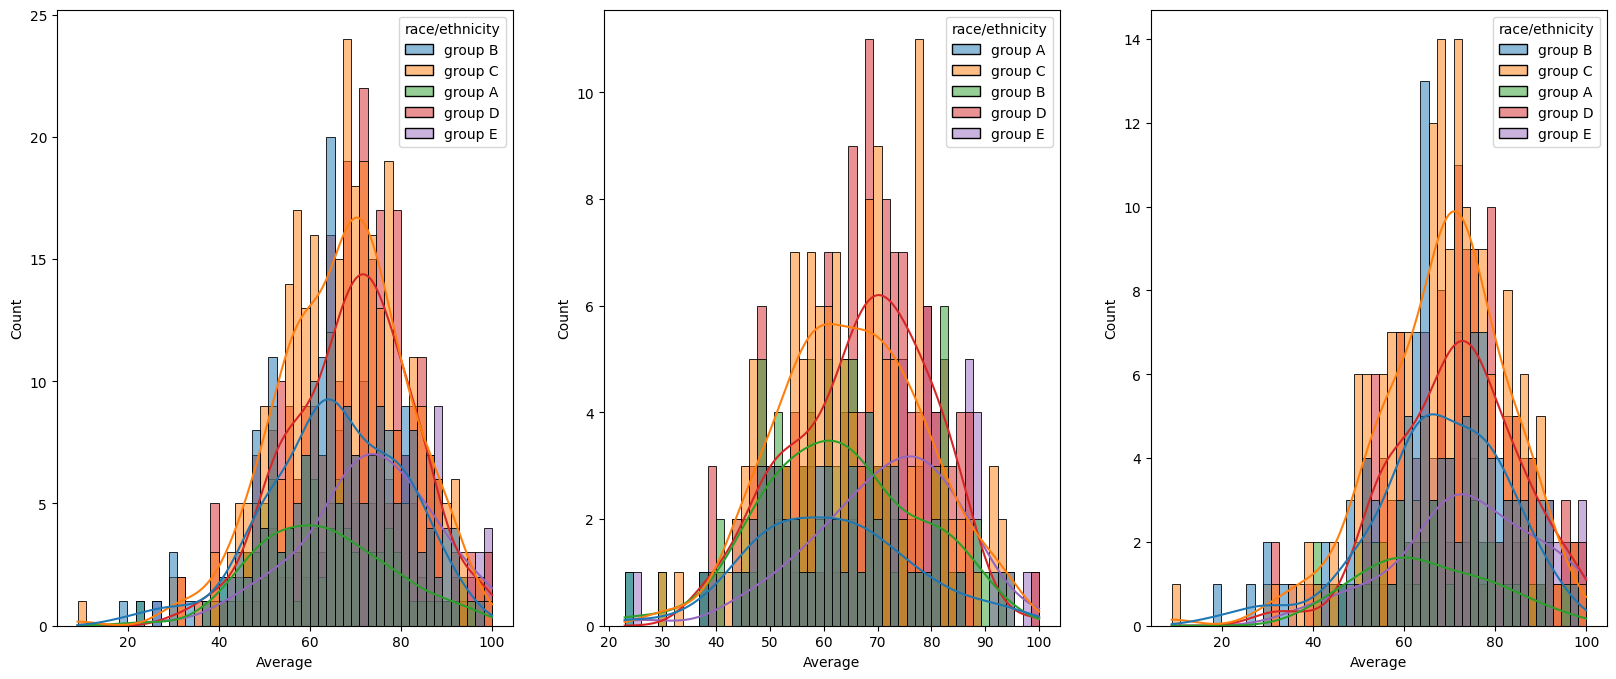

In [41]:
plt.subplots(1,3,figsize = (20,8))
plt.subplot(131)
sns.histplot(data=df,x="Average",bins=50,kde=True,hue = "race/ethnicity")
plt.subplot(132)
sns.histplot(data=df[df['gender'] == 'male'],x="Average",bins=50,kde=True, hue='race/ethnicity')
plt.subplot(133)
sns.histplot(data=df[df['gender'] == 'female'],x="Average",bins=50,kde=True, hue='race/ethnicity')

##### Insights:

- In subplot # 1: Group C seems to be the most scoring class as in all the three plots C's score is quite high especially in the females ones
- Group A has the most low score
- In males the dominant fields are of group D

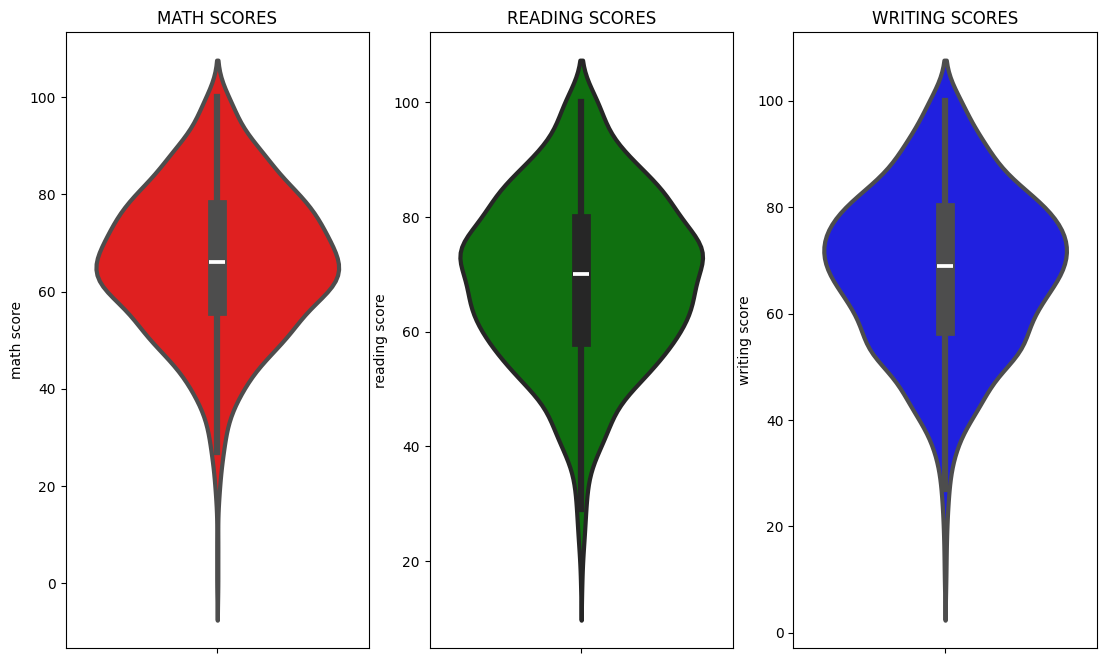

In [45]:

plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing score',data=df,color='blue',linewidth=3)
plt.show()

#### Insights
- From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80

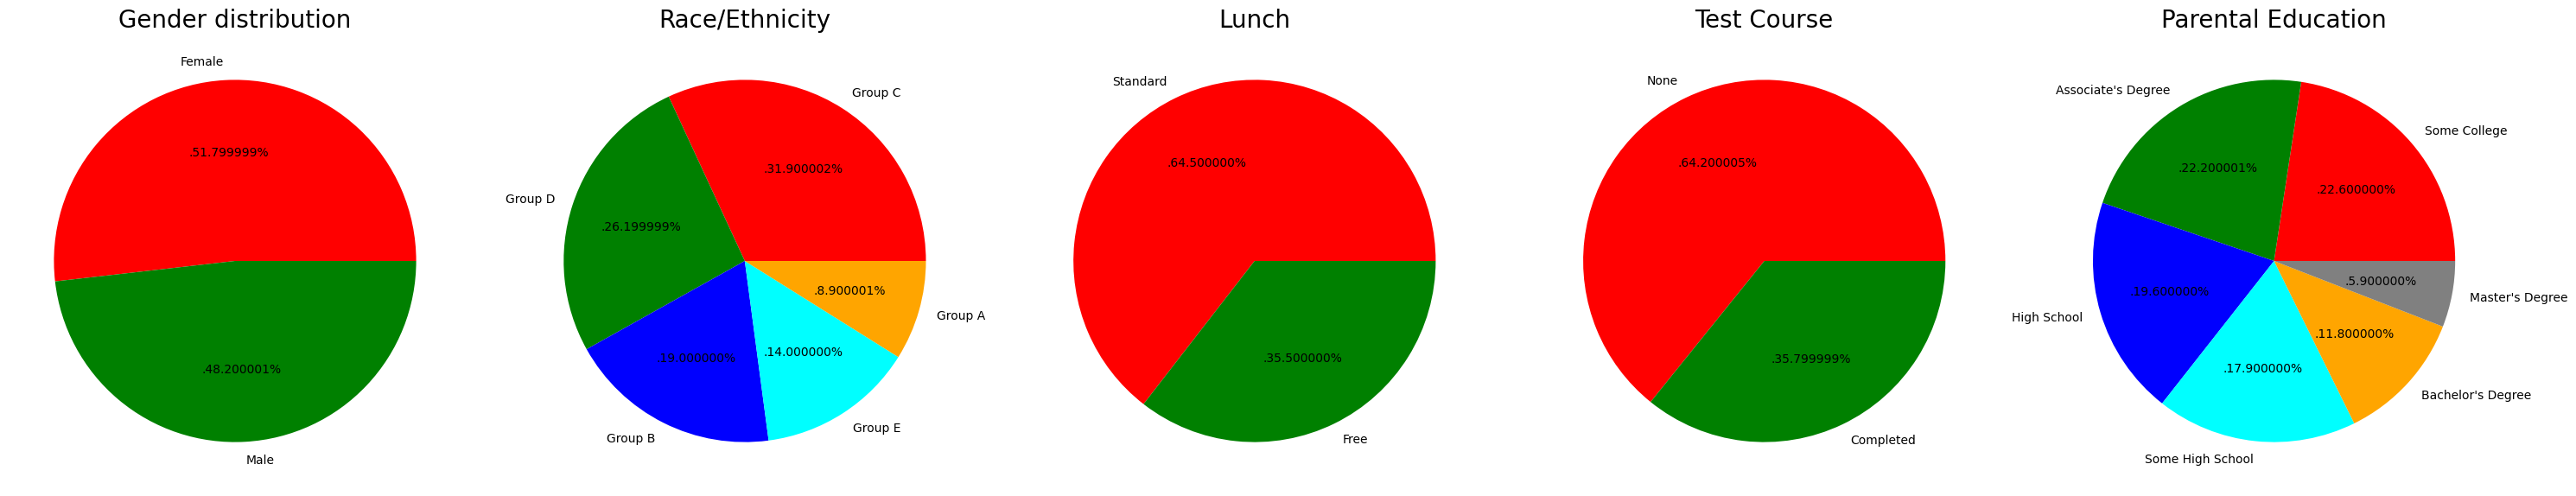

In [59]:
plt.rcParams['figure.figsize'] = (30, 12)
plt.subplots(1,5)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red', 'green']

plt.subplot(151)
plt.pie(size,colors = color, labels = labels,autopct = '.%2f%%')
plt.title("Gender distribution", fontsize = 20)
plt.axis("off")

size = df['race/ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.subplot(152)
plt.pie(size,colors = color, labels = labels,autopct = '.%2f%%')
plt.title("Race/Ethnicity", fontsize = 20)
plt.axis("off")

size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red', 'green']

plt.subplot(153)
plt.pie(size,colors = color, labels = labels,autopct = '.%2f%%')
plt.title("Lunch", fontsize = 20)
plt.axis("off")

plt.subplot(1, 5, 4)
size = df['test preparation course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental level of education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

#####  Insights
- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

([<matplotlib.patches.Wedge at 0x23b70dcca90>,
 [Text(-0.062170487413935493, 1.0982416994881927, 'Male'),
  Text(0.06782216900078375, -1.1980818642279956, 'Female')],
 [Text(-0.03391117495305572, 0.5990409269935596, '51.8%'),
  Text(0.039562931917123845, -0.6988810874663307, '48.2%')])

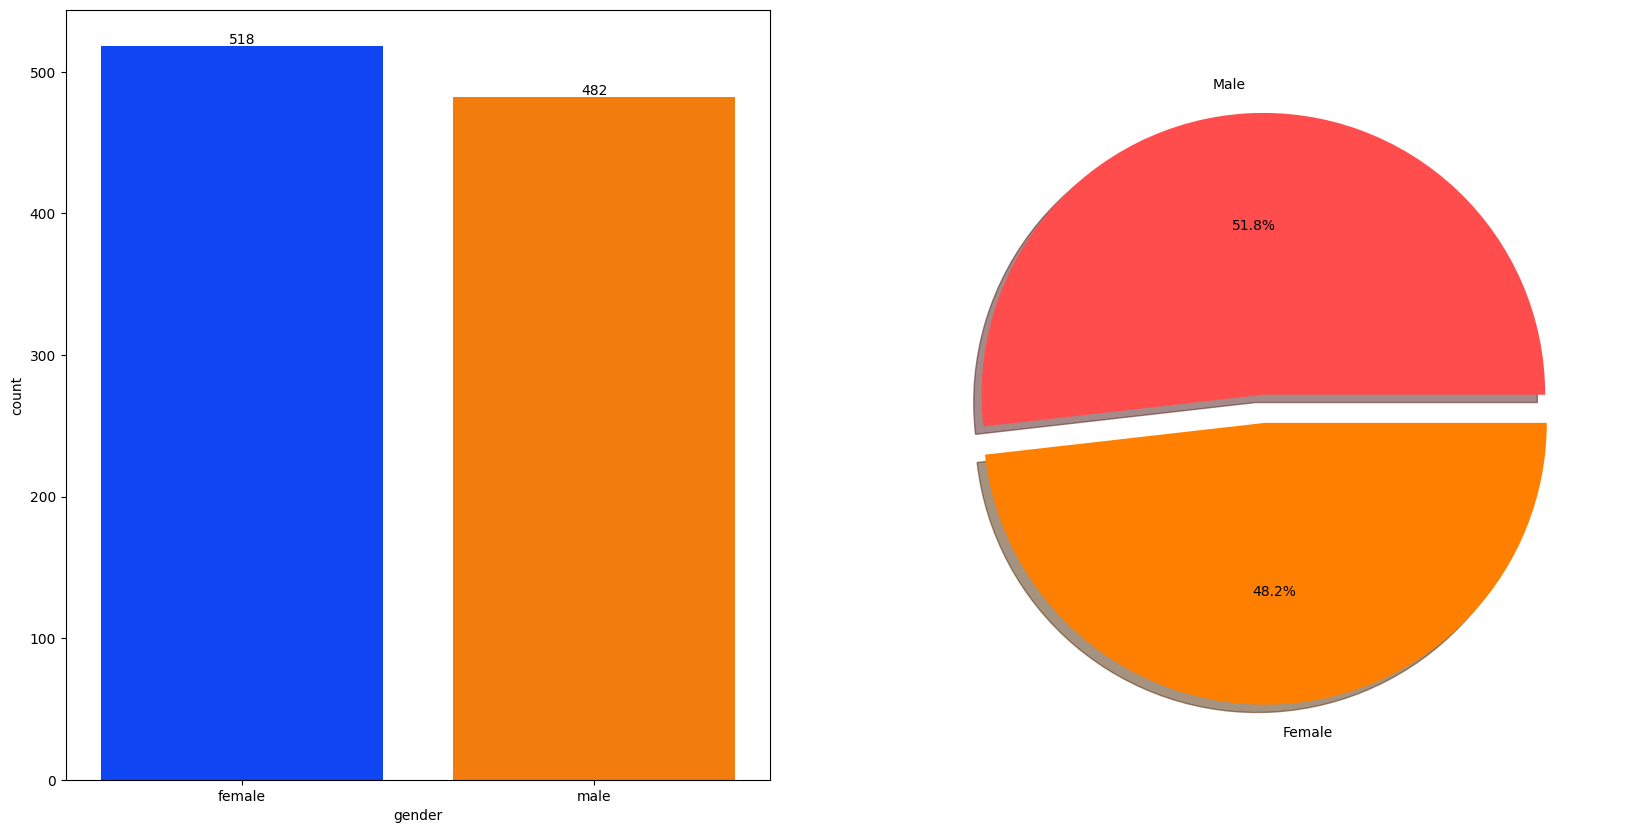

In [78]:
ffi,ax = plt.subplots(1,2,figsize = (20,10))
sns.countplot(x= df['gender'],data = df, palette="bright",ax = ax[0], saturation=0.90)

for container in ax[0].containers:
    ax[0].bar_label(container, fontsize=10)

plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])


##### Insights:
- Dataset is completely balanced with respect to gender

In [90]:
gender_group = df.groupby("gender").mean(numeric_only=True)
gender_group

,math score,reading score,writing score,Score,Average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


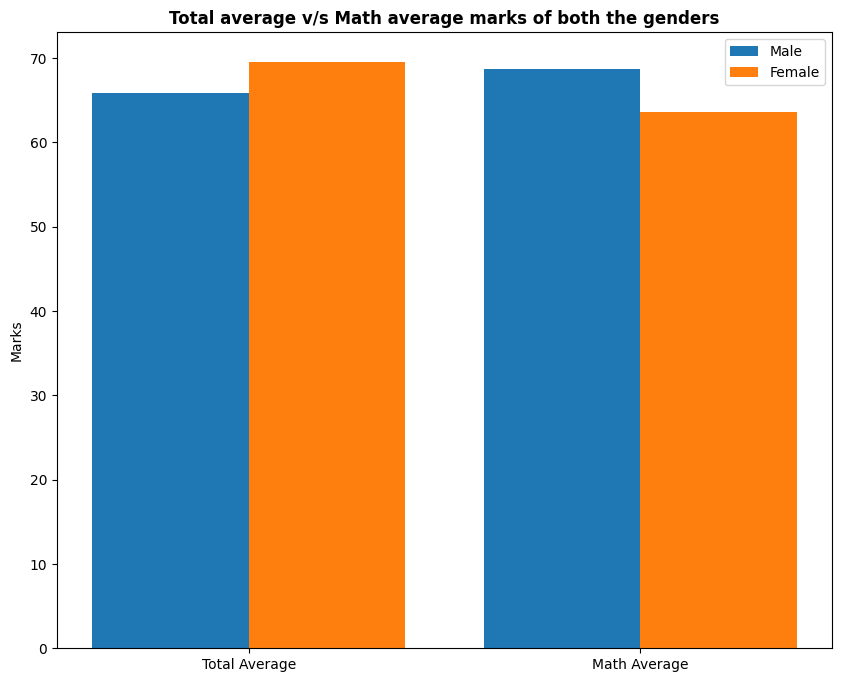

In [97]:
plt.figure(figsize=(10, 8))

X = ['Total Average','Math Average']

female_scores = [gender_group['Average'][0], gender_group['math score'][0]]
male_scores = [gender_group['Average'][1], gender_group['math score'][1]]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

##### Insights:

- Female students are much better performer than male candidates
- Male students are much better performer than female candidates in maths


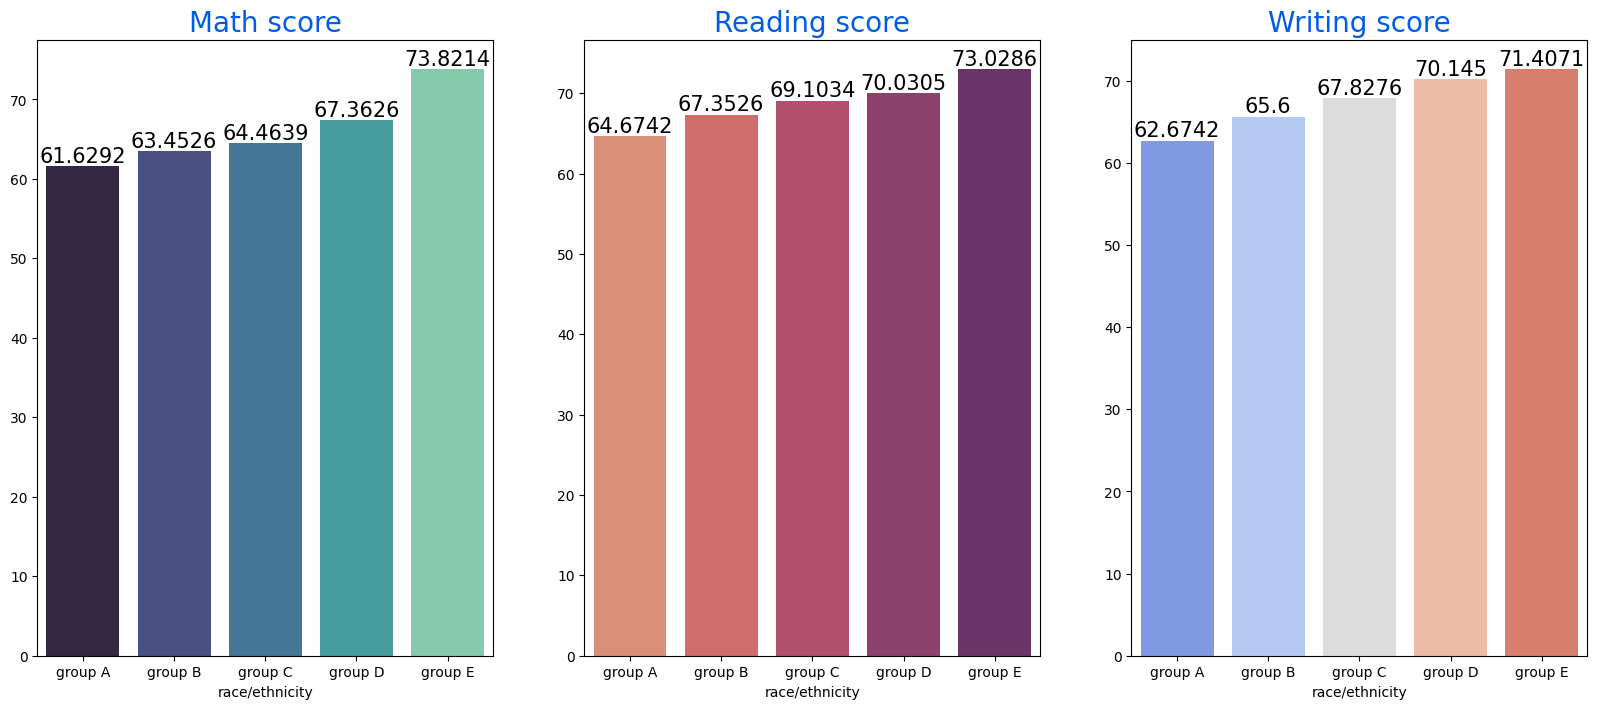

In [98]:
Group_data2=df.groupby('race/ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math score'].mean().index,y=Group_data2['math score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading score'].mean().index,y=Group_data2['reading score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing score'].mean().index,y=Group_data2['writing score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

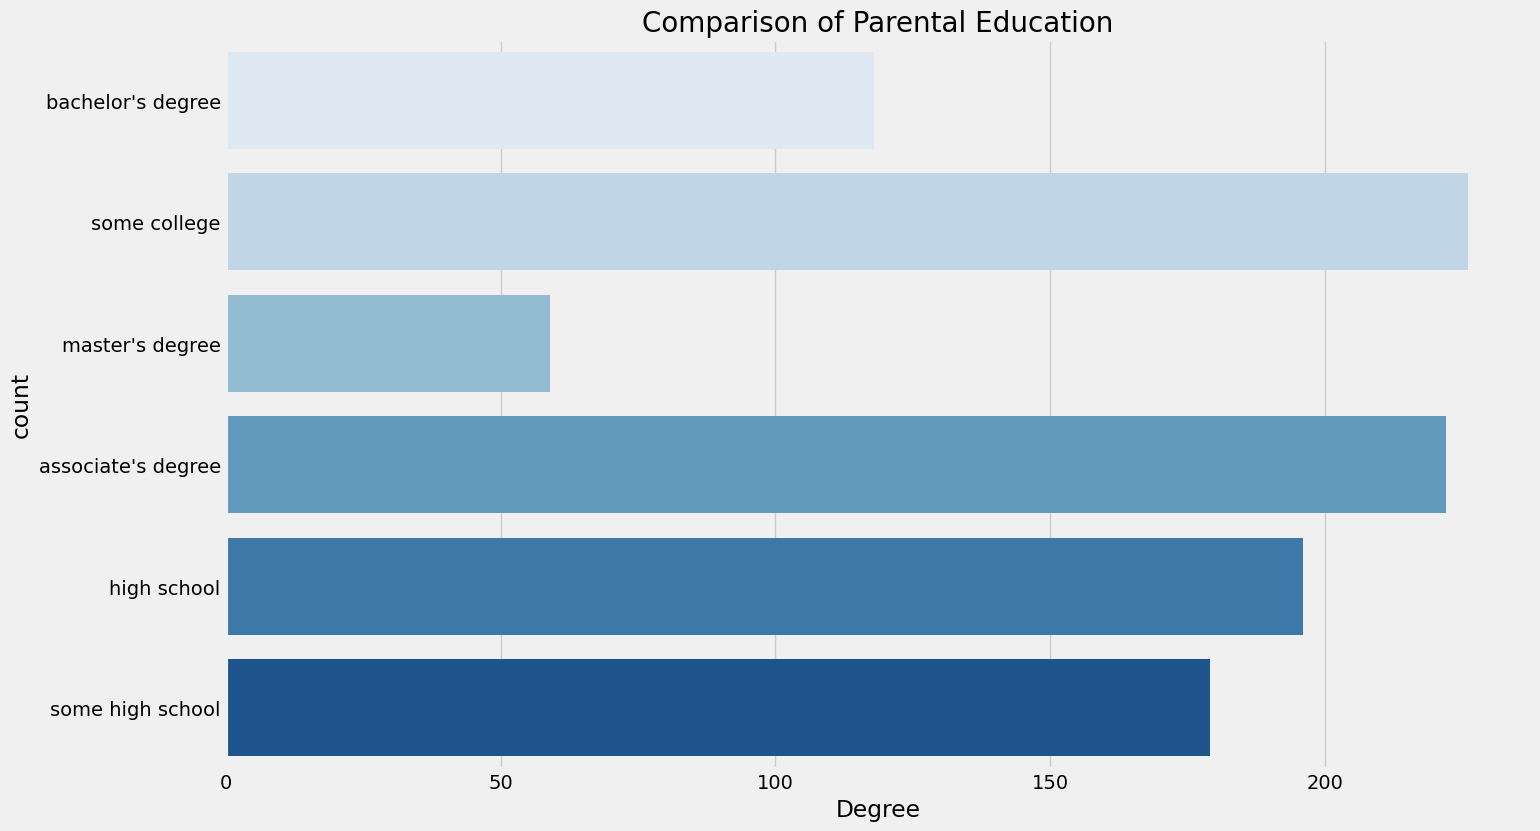

In [99]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental level of education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

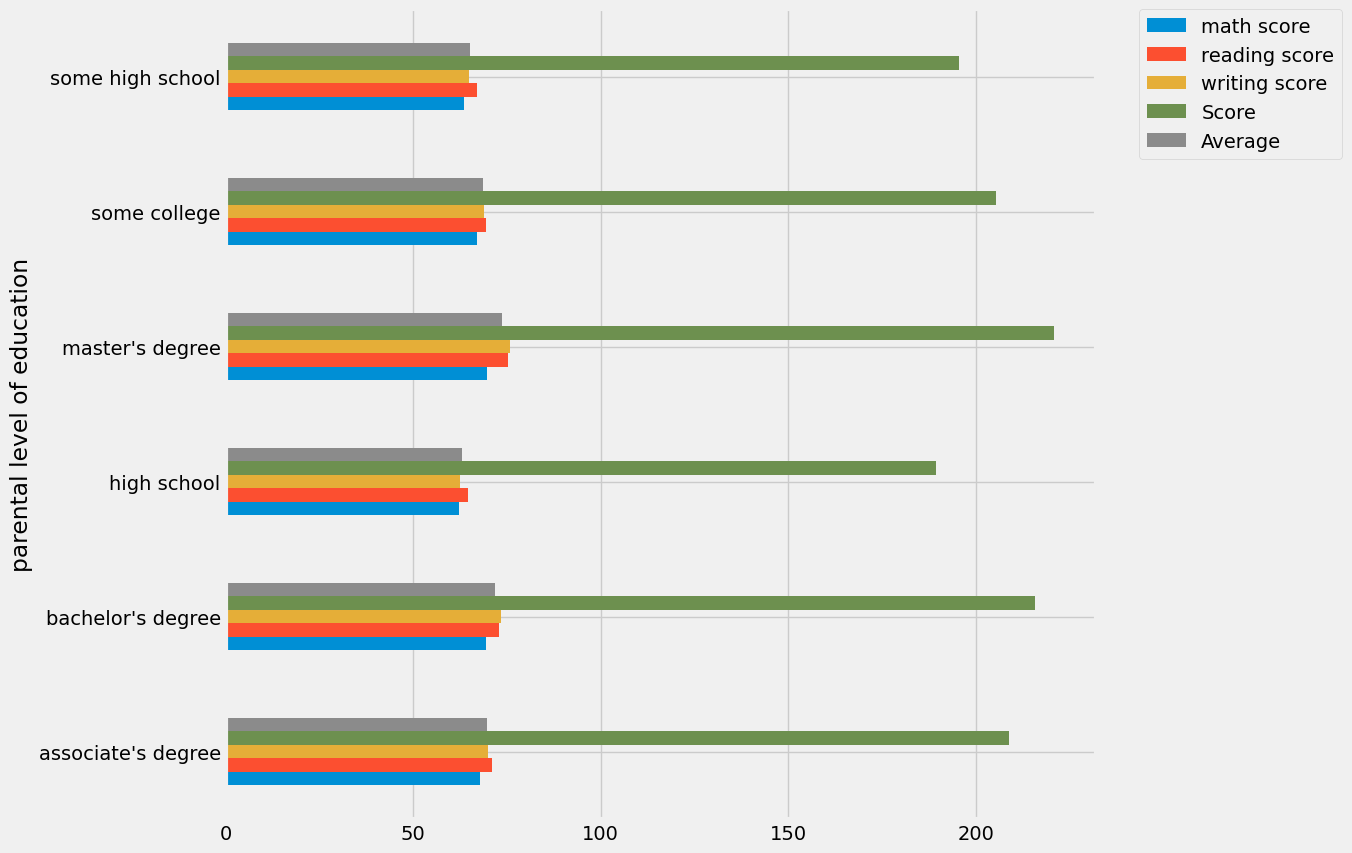

In [101]:
df.groupby('parental level of education').mean(numeric_only=True).plot(kind='barh',figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

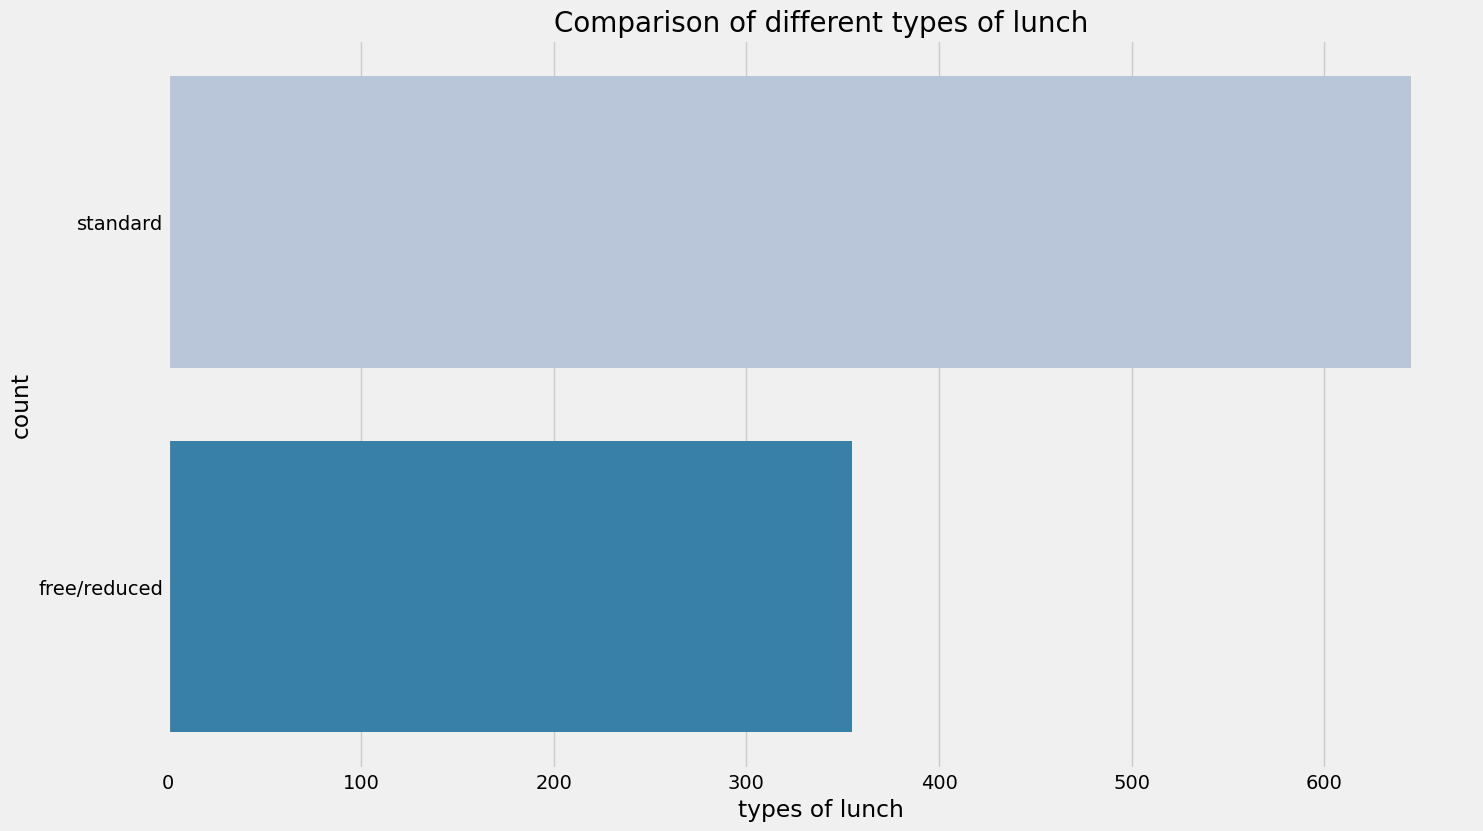

In [103]:
plt.rcParams['figure.figsize'] = (15, 9)
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

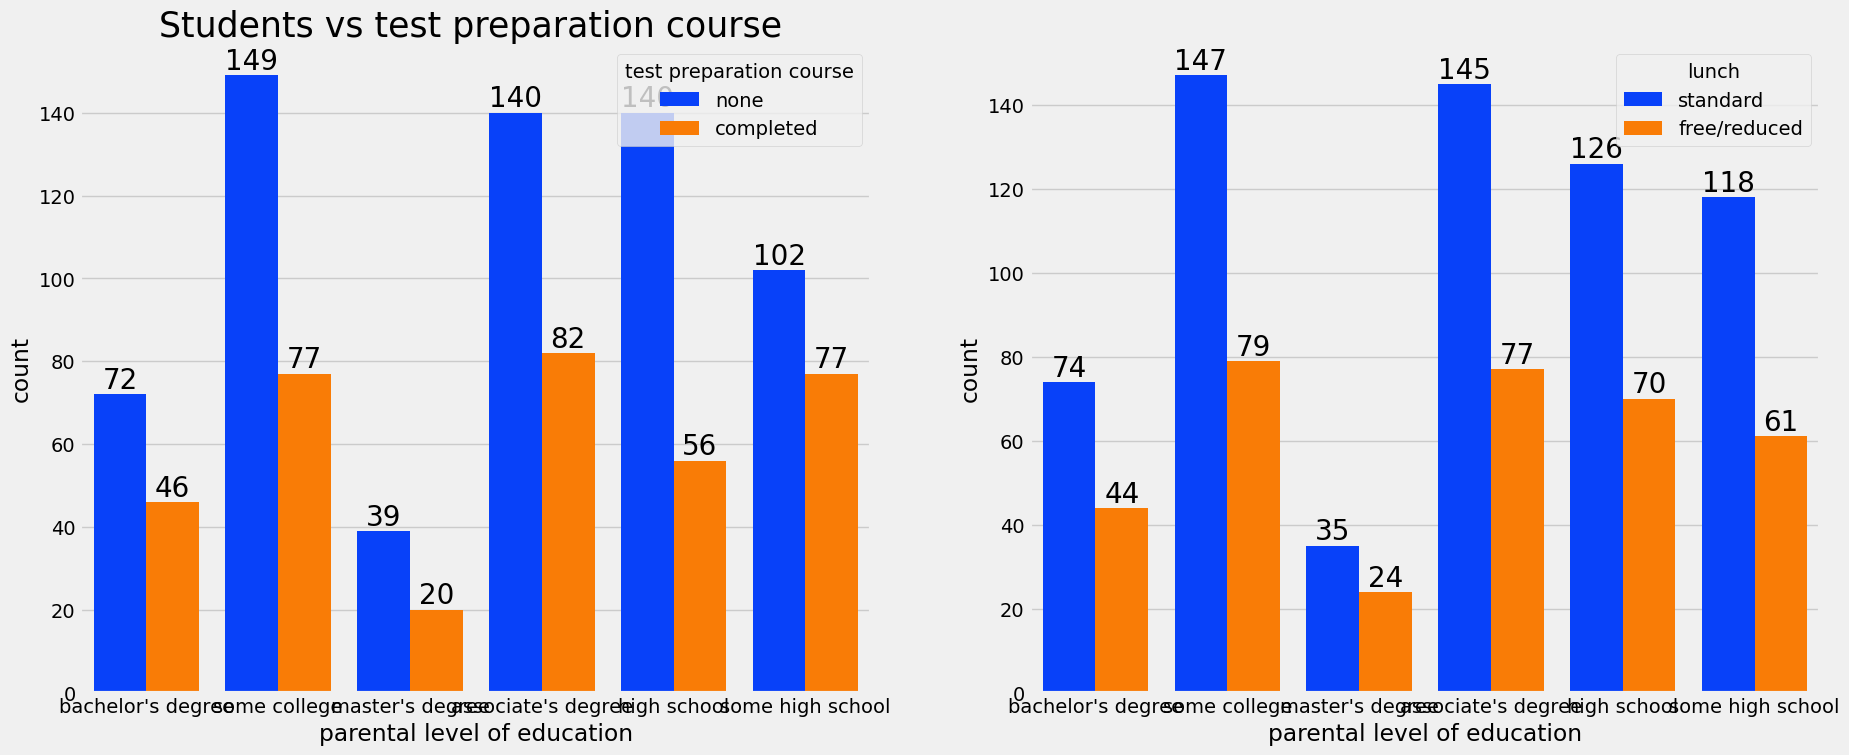

In [104]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=df['parental level of education'],data=df,palette = 'bright',hue='test preparation course',saturation=0.95,ax=ax[0])
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
sns.countplot(x=df['parental level of education'],data=df,palette = 'bright',hue='lunch',saturation=0.95,ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20)   

<Axes: xlabel='lunch', ylabel='writing score'>

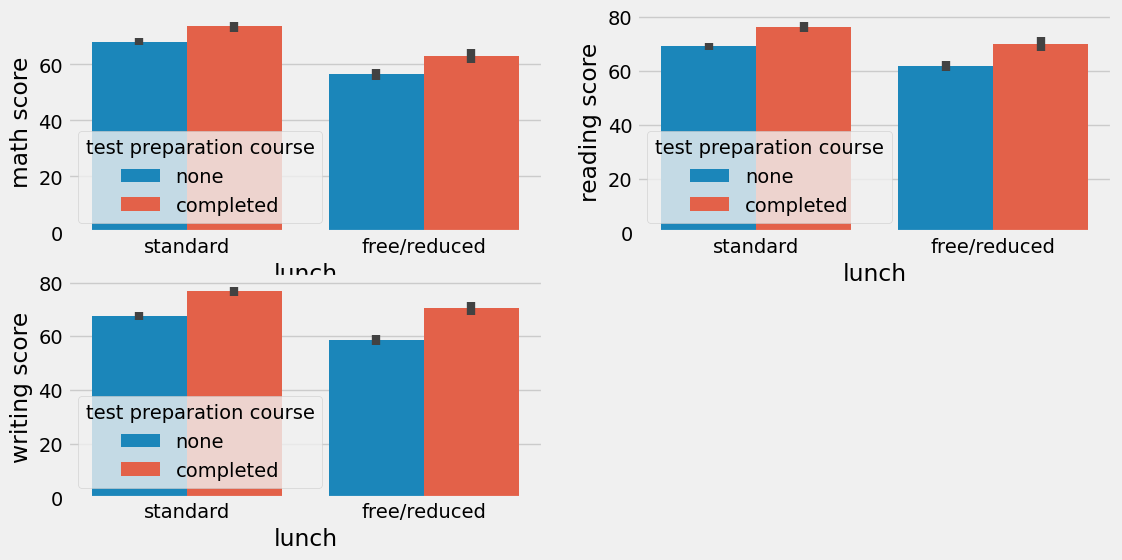

In [105]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot (x=df['lunch'], y=df['math score'], hue=df['test preparation course'])
plt.subplot(2,2,2)
sns.barplot (x=df['lunch'], y=df['reading score'], hue=df['test preparation course'])
plt.subplot(2,2,3)
sns.barplot (x=df['lunch'], y=df['writing score'], hue=df['test preparation course'])

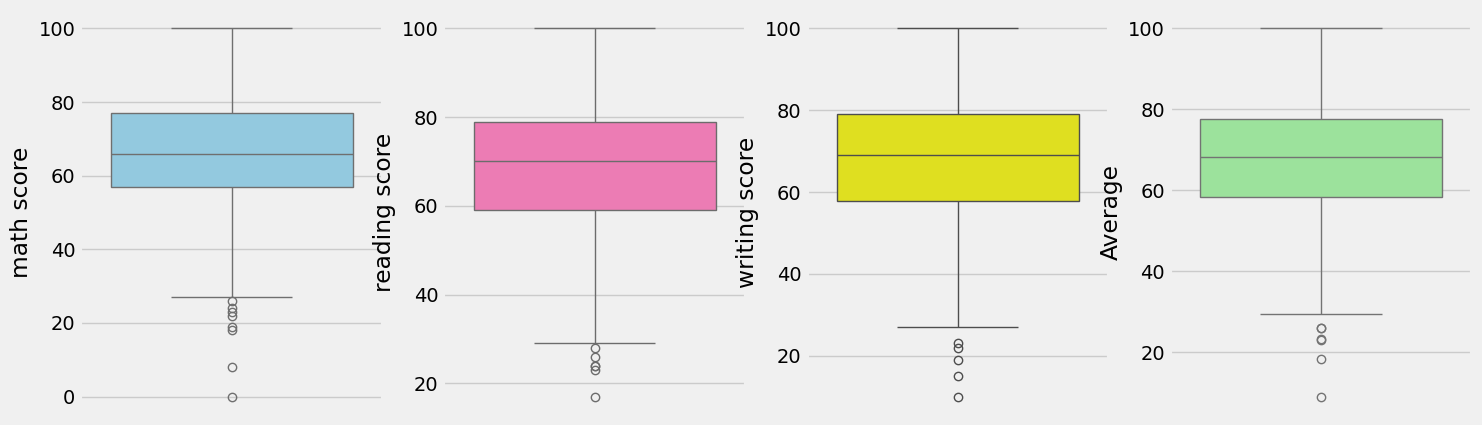

In [108]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['Average'],color='lightgreen')
plt.show()

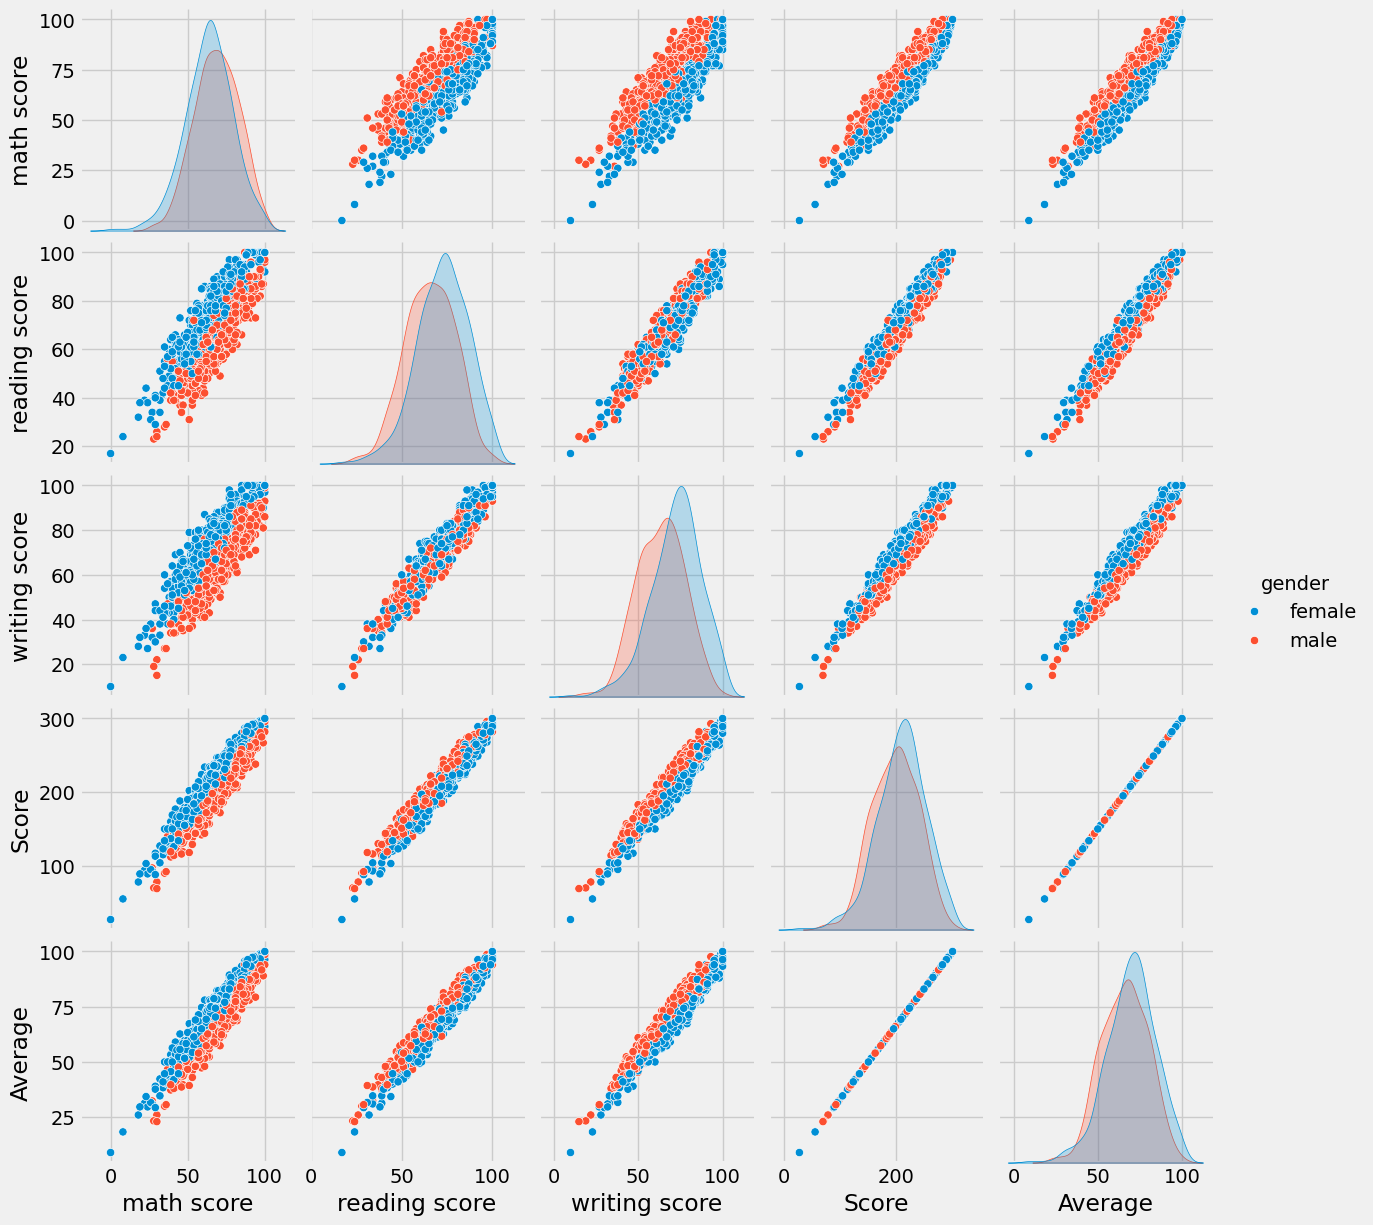

In [107]:
sns.pairplot(df,hue = 'gender')
plt.show()